In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import gaussian_filter1d

In [27]:
sm=5

In [159]:
# Load the data
df = pd.read_csv(
    './for_deg/fork_deg_findl_3and_5hrs/matrix_fork_deg_3hrs_genome_region_le2.gz',
    compression='gzip', sep='\t', skiprows=[0], header=None
)
df = df.fillna(0.0)
df_locations = df[[0, 1, 2]]
df = df.drop([0, 1, 2, 3, 4, 5], axis=1)
ctcf_array = df.to_numpy()
df 

,6,7,8,9,10,11,12,13,14,15,...,436,437,438,439,440,441,442,443,444,445
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.676928,3.018363,0.602900,3.047102,0.000000,0.000000,1.532013,5.711567,0.784123,0.853792
1,0.573313,1.407625,0.314110,3.131279,0.000000,0.000000,1.866625,1.750170,1.481877,2.382878,...,0.335040,0.000000,1.846558,0.000000,1.630293,3.046536,2.747736,2.598810,0.191536,2.588868
2,0.853210,0.583665,1.115654,1.584396,6.982995,7.625114,1.750530,1.193430,2.090890,0.573545,...,0.000000,0.000000,6.851542,2.152010,0.000000,0.000000,0.000000,0.000000,1.044320,10.387182
3,0.495020,0.000000,0.970220,0.909620,2.449201,0.721810,2.323537,3.590007,0.000000,12.008766,...,1.247933,0.121110,1.451771,2.210780,0.963580,1.800763,0.000000,0.000000,1.380855,1.812078
4,0.703812,4.117431,0.000000,0.847820,0.357305,0.909464,0.237156,0.000000,0.145802,0.660976,...,3.055210,1.141938,3.845673,2.809713,2.261790,0.000000,1.004034,1.303829,0.281707,0.432288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48541,2.743604,0.000000,0.000000,0.000000,0.383415,0.000000,0.000000,0.000000,5.325198,0.000000,...,1.044320,1.410465,1.440080,0.000000,0.000000,1.638397,5.778107,2.329708,1.497798,1.592010
48542,0.000000,0.733692,2.312134,0.000000,1.269022,0.000000,0.000000,6.850303,0.913813,1.258225,...,0.746116,2.388642,0.000000,0.000000,4.436057,3.775436,2.777828,3.088790,0.000000,0.000000
48543,0.000000,0.000000,8.946508,2.261437,0.000000,7.266470,12.798748,1.463551,1.313896,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
48544,6.217822,2.394578,0.000000,0.591315,2.380927,3.159350,3.981210,2.511034,4.560367,4.511092,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [160]:
# df_locations.to_csv('./for_deg/fork_deg_findl_3and_5hrs/locations_le2_same.bed', sep='\t', header=None, index=None)

In [161]:
# ========================
# USER / HARDCODED SETUP
# ========================
# Order here MUST match the column layout in ctcf_array along axis=1
var_names = [
    "UT",
    "IR",
    "WT_HU",
    "WT_BrdU_FT",
    "WT_mirin",
    "G9ai",
    "G9ai_mirin",
    "CTCFkd",
    "CTCFkd_mirin",
    "DKD",
    "DKD_mirin"
]

# Number of splits = number of names
n_splits = len(var_names)

# ========================
# SPLIT ONCE
# ========================
split_arrays = np.split(ctcf_array, n_splits, axis=1)

# Map each name -> its slice
arrays = {name: arr for name, arr in zip(var_names, split_arrays)}

# ========================
# STATS CONTAINERS
# ========================
means = {}
stds_early = {}
means_early = {}

# ========================
# LOOP OVER ALL NAMED SLICES
# ========================
for name in var_names:
    # skip x (coordinate axis)
    if name == "x":
        continue

    arr = arrays[name]              # shape (N, M)
    mask = arr != 0                 # ignore zeros
    count = np.sum(mask, axis=0)    # per-column nonzero counts

    mean = np.zeros(arr.shape[1], dtype=float)
    std = np.zeros(arr.shape[1], dtype=float)

    valid = count > 0               # avoid division by zero

    # mean over non-zero entries
    mean[valid] = (
        np.sum(arr[:, valid] * mask[:, valid], axis=0) / count[valid]
    )

    # std over non-zero entries
    std[valid] = np.sqrt(
        np.sum(
            mask[:, valid] * (arr[:, valid] - mean[valid]) ** 2,
            axis=0
        ) / count[valid]
    )

    means[name] = mean
    stds_early[name] = std
    means_early[name] = gaussian_filter1d(mean, sigma=sm)
    
shift = 0.1
means_early['DKD'] = np.array(means_early['DKD'])  shift

/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_5959/1687725184.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


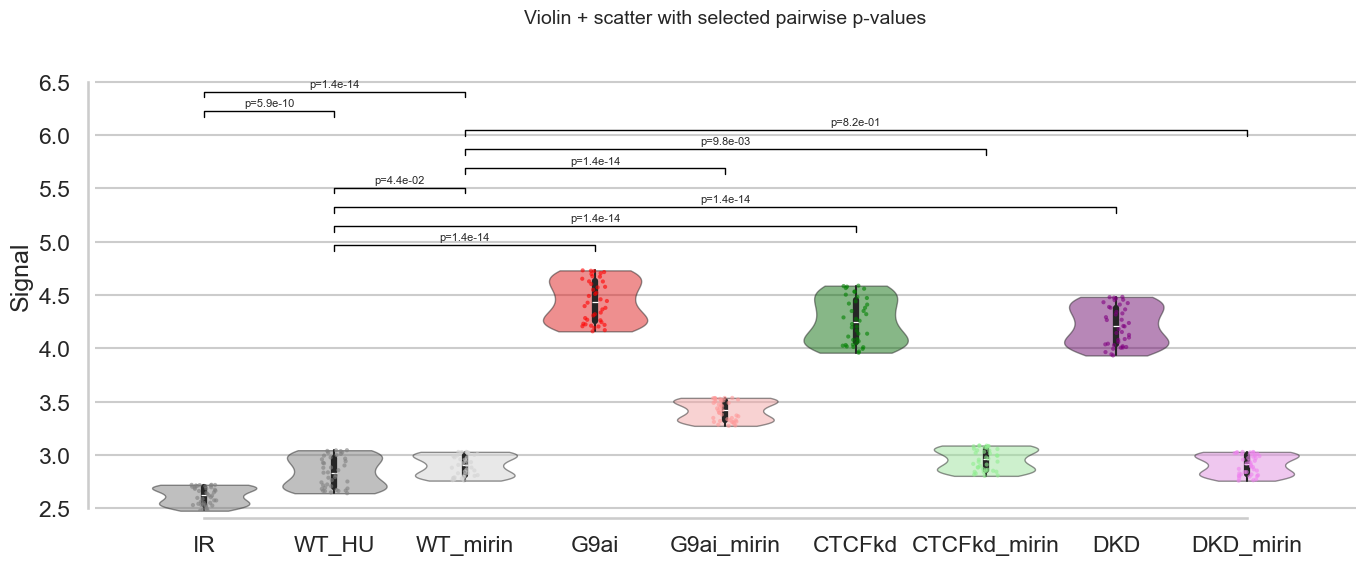

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) Conditions to plot (UT and WT_BrdU_FT removed)
# ------------------------------------------------------------
order = [
    "IR",
    "WT_HU", "WT_mirin",
    "G9ai", "G9ai_mirin",
    "CTCFkd", "CTCFkd_mirin",
    "DKD", "DKD_mirin",
]

# ------------------------------------------------------------
# 3) Tidy DataFrame
# ------------------------------------------------------------
rows = []
for cond in order:
    arr = data[cond]
    for v in arr:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette: WT/G9ai/CTCFkd/DKD with lighter mirin shades
# ------------------------------------------------------------
cond_palette = {
    "IR":         "grey",
    "WT_HU":      "grey",
    "WT_mirin":   "lightgrey",

    "G9ai":       "red",
    "G9ai_mirin": "#ff9999",

    "CTCFkd":       "green",
    "CTCFkd_mirin": "lightgreen",

    "DKD":       "purple",
    "DKD_mirin": "violet",
}

# ------------------------------------------------------------
# 5) Violin + scatter
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    palette=cond_palette,
    inner="box",
    cut=0,
    linewidth=1.0,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    hue="Condition",
    hue_order=order,
    palette=cond_palette,
    dodge=False,
    size=3,
    alpha=0.6,
    legend=False,
    ax=ax
)

# ------------------------------------------------------------
# 6) Define specific comparison pairs
# ------------------------------------------------------------
pairs = []

# WT vs {G9ai, CTCFkd, DKD, WT_mirin}
pairs.extend([
    (WT_KEY, "G9ai"),
    (WT_KEY, "CTCFkd"),
    (WT_KEY, "DKD"),
    (WT_KEY, "WT_mirin"),
])

# WT_mirin vs {G9ai_mirin, CTCFkd_mirin, DKD_mirin}
pairs.extend([
    ("WT_mirin", "G9ai_mirin"),
    ("WT_mirin", "CTCFkd_mirin"),
    ("WT_mirin", "DKD_mirin"),
])

# IR vs {WT, WT_mirin}
pairs.extend([
    ("IR", WT_KEY),
    ("IR", "WT_mirin"),
])

# ------------------------------------------------------------
# 7) Compute and plot p-values (Mann–Whitney U)
# ------------------------------------------------------------
y_min = df["Value"].min()
y_max = df["Value"].max()
step = (y_max - y_min) * 0.08   # vertical spacing between brackets
top = y_max

for i, (c1, c2) in enumerate(pairs):
    x1 = order.index(c1)
    x2 = order.index(c2)

    g1 = df.loc[df["Condition"] == c1, "Value"]
    g2 = df.loc[df["Condition"] == c2, "Value"]

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    y = top + step * (i + 1)
    y_top = y + 0.3 * step
    y_text = y + 0.45 * step

    # bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.0,
        c="black"
    )

    # p-value text
    ax.text(
        (x1 + x2) / 2,
        y_text,
        f"p={pval:.1e}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_ylim(y_min, top + step * (len(pairs) + 3))

# ------------------------------------------------------------
# 8) Cosmetics
# ------------------------------------------------------------
ax.set_title("Violin + scatter with selected pairwise p-values", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Signal")
plt.xticks(rotation=90)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_3hrs_lessthan2_violin.svg", format="svg", dpi=1200)
plt.show()


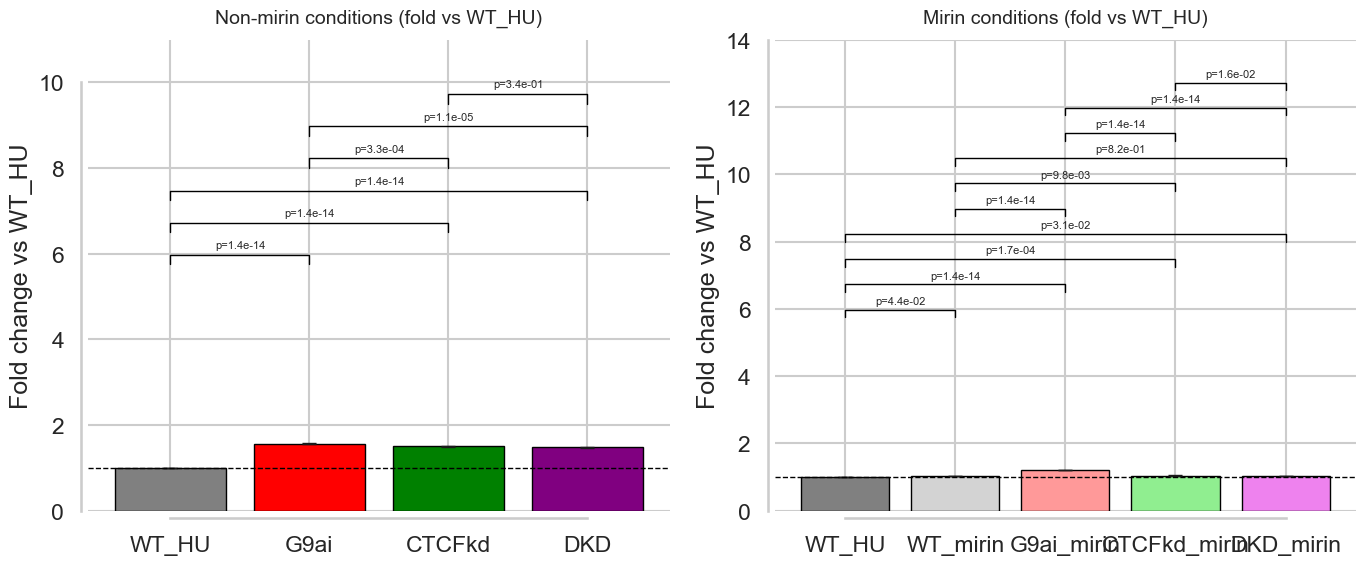

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early  # dict-like: key -> 1D array/list

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) All conditions (for df)
# ------------------------------------------------------------
order = [
    "IR",
    "WT_HU", "WT_mirin",
    "G9ai", "G9ai_mirin",
    "CTCFkd", "CTCFkd_mirin",
    "DKD", "DKD_mirin",
]

# ------------------------------------------------------------
# 3) Tidy DataFrame (raw values)
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette
# ------------------------------------------------------------
cond_palette = {
    "IR":           "grey",
    "WT_HU":        "grey",
    "WT_mirin":     "lightgrey",

    "G9ai":         "red",
    "G9ai_mirin":   "#ff9999",

    "CTCFkd":       "green",
    "CTCFkd_mirin": "lightgreen",

    "DKD":          "purple",
    "DKD_mirin":    "violet",
}

# ------------------------------------------------------------
# 5) Helper: make one fold-change bar plot with p-values
# ------------------------------------------------------------
def make_fc_bar(ax, subset, title):
    """
    subset: list of condition names to show as bars
    title:  subplot title
    """
    # WT baseline mean
    wt_vals = np.asarray(data[WT_KEY], dtype=float)
    wt_mean = wt_vals.mean()

    # fold-change stats
    fc_means = []
    fc_sems  = []

    for cond in subset:
        vals = np.asarray(data[cond], dtype=float)
        fc_vals = vals / wt_mean  # per-replicate fold change

        fc_means.append(fc_vals.mean())
        if len(fc_vals) > 1:
            fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
        else:
            fc_sems.append(0.0)

    fc_means = np.array(fc_means)
    fc_sems  = np.array(fc_sems)

    # bar plot
    x = np.arange(len(subset))

    bars = ax.bar(
        x,
        fc_means,
        yerr=fc_sems,
        capsize=5,
        linewidth=1.0,
        edgecolor="black",
    )

    for bar, cond in zip(bars, subset):
        bar.set_facecolor(cond_palette[cond])

    # baseline WT fold change = 1
    ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(subset, rotation=90)
    ax.set_ylabel("Fold change vs WT_HU")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=12)

    # --- all pairwise p-values within this subset ---
    cond_to_x = {c: i for i, c in enumerate(subset)}
    pairs = list(combinations(subset, 2))

    y_max = 5
    y_min = 0.0
    step  = y_max * 0.15
    top   = y_max

    for i, (c1, c2) in enumerate(pairs):
        x1 = cond_to_x[c1]
        x2 = cond_to_x[c2]

        g1 = df.loc[df["Condition"] == c1, "Value"]
        g2 = df.loc[df["Condition"] == c2, "Value"]

        stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

        y = top + step * (i + 1)
        y_top = y + 0.3 * step
        y_text = y + 0.45 * step

        # bracket
        ax.plot(
            [x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.0,
            c="black",
        )

        # p-value text
        ax.text(
            (x1 + x2) / 2,
            y_text,
            f"p={pval:.1e}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_ylim(y_min, top + step * (len(pairs) + 2))

# ------------------------------------------------------------
# 6) Two subplots:
#    1) WT_HU, G9ai, CTCFkd, DKD
#    2) WT_mirin, G9ai_mirin, CTCFkd_mirin, DKD_mirin
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

subset1 = ["WT_HU", "G9ai", "CTCFkd", "DKD"]
subset2 = ["WT_HU", "WT_mirin", "G9ai_mirin", "CTCFkd_mirin", "DKD_mirin"]

make_fc_bar(axes[0], subset1, "Non-mirin conditions (fold vs WT_HU)")
make_fc_bar(axes[1], subset2, "Mirin conditions (fold vs WT_HU)")

for ax in axes:
    sns.despine(ax=ax, offset=5, trim=True)

plt.tight_layout()
plt.savefig("./fig_1/hct_3hrs_greterthan2_foldchange_bar_dual.svg",
            format="svg", dpi=1200)
plt.show()


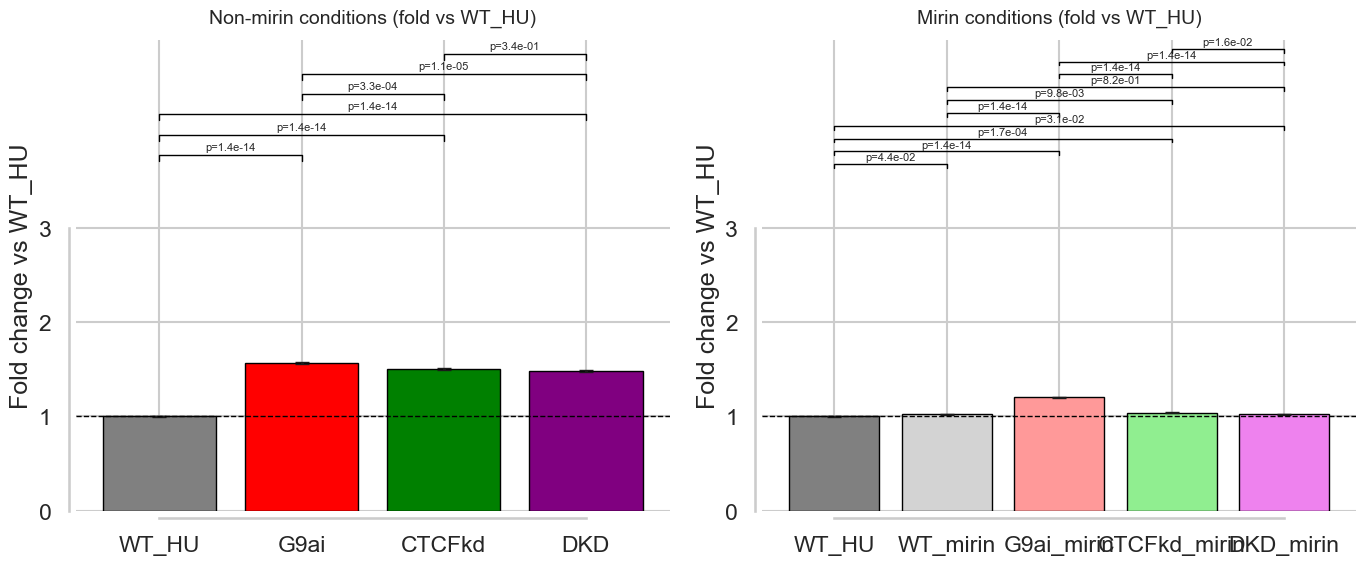

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early  # dict-like: key -> 1D array/list

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) All conditions (for df)
# ------------------------------------------------------------
order = [
    "IR",
    "WT_HU", "WT_mirin",
    "G9ai", "G9ai_mirin",
    "CTCFkd", "CTCFkd_mirin",
    "DKD", "DKD_mirin",
]

# ------------------------------------------------------------
# 3) Tidy DataFrame (raw values)
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette
# ------------------------------------------------------------
cond_palette = {
    "IR":           "grey",
    "WT_HU":        "grey",
    "WT_mirin":     "lightgrey",

    "G9ai":         "red",
    "G9ai_mirin":   "#ff9999",

    "CTCFkd":       "green",
    "CTCFkd_mirin": "lightgreen",

    "DKD":          "purple",
    "DKD_mirin":    "violet",
}

# ------------------------------------------------------------
# 5) Helper: make one fold-change bar plot with p-values
# ------------------------------------------------------------
def make_fc_bar(ax, subset, title):
    """
    subset: list of condition names to show as bars
    title:  subplot title
    """
    # WT baseline mean
    wt_vals = np.asarray(data[WT_KEY], dtype=float)
    wt_mean = wt_vals.mean()

    # fold-change stats
    fc_means = []
    fc_sems  = []

    for cond in subset:
        vals = np.asarray(data[cond], dtype=float)
        fc_vals = vals / wt_mean  # per-replicate fold change

        fc_means.append(fc_vals.mean())
        if len(fc_vals) > 1:
            fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
        else:
            fc_sems.append(0.0)

    fc_means = np.array(fc_means)
    fc_sems  = np.array(fc_sems)

    # bar plot
    x = np.arange(len(subset))

    bars = ax.bar(
        x,
        fc_means,
        yerr=fc_sems,
        capsize=5,
        linewidth=1.0,
        edgecolor="black",
    )

    for bar, cond in zip(bars, subset):
        bar.set_facecolor(cond_palette[cond])

    # baseline WT fold change = 1
    ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(subset, rotation=90)
    ax.set_ylabel("Fold change vs WT_HU")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=12)

    # --- all pairwise p-values within this subset ---
    cond_to_x = {c: i for i, c in enumerate(subset)}
    pairs = list(combinations(subset, 2))

    # axis limits: bars + p-values in same axis, capped at 5
    y_min = 0.0
    y_max_plot = 5.0

    # where bars end
    data_top = (fc_means + fc_sems).max()

    # allocate top slice [pv_bottom, 5] for p-values
    # push it above data_top, but at least 3.5
    pv_bottom = max(data_top + 0.2, 3.5)
    if pv_bottom >= y_max_plot:
        pv_bottom = y_max_plot - 0.5  # safety fallback

    pv_top = y_max_plot
    available = pv_top - pv_bottom
    step = available / (len(pairs) + 1)

    for i, (c1, c2) in enumerate(pairs):
        x1 = cond_to_x[c1]
        x2 = cond_to_x[c2]

        g1 = df.loc[df["Condition"] == c1, "Value"]
        g2 = df.loc[df["Condition"] == c2, "Value"]

        stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

        y = pv_bottom + step * (i + 1)
        y_top = y + step * 0.3
        y_text = y + step * 0.45

        # bracket
        ax.plot(
            [x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.0,
            c="black",
        )

        # p-value text
        ax.text(
            (x1 + x2) / 2,
            y_text,
            f"p={pval:.1e}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # final axis settings: limit to 5, hide ticks in p-value region
    ax.set_ylim(y_min, y_max_plot)
    ax.set_yticks([0, 1, 2, 3])  # no tick numbers in the top (p-value) slice

# ------------------------------------------------------------
# 6) Two subplots:
#    1) WT_HU, G9ai, CTCFkd, DKD
#    2) WT_HU, WT_mirin, G9ai_mirin, CTCFkd_mirin, DKD_mirin
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

subset1 = ["WT_HU", "G9ai", "CTCFkd", "DKD"]
subset2 = ["WT_HU", "WT_mirin", "G9ai_mirin", "CTCFkd_mirin", "DKD_mirin"]

make_fc_bar(axes[0], subset1, "Non-mirin conditions (fold vs WT_HU)")
make_fc_bar(axes[1], subset2, "Mirin conditions (fold vs WT_HU)")

for ax in axes:
    sns.despine(ax=ax, offset=5, trim=True)

plt.tight_layout()
plt.savefig("./fig_1/hct_3hrs_lessthan2_foldchange_bar_dual_5.svg",
            format="svg", dpi=1200)
plt.show()


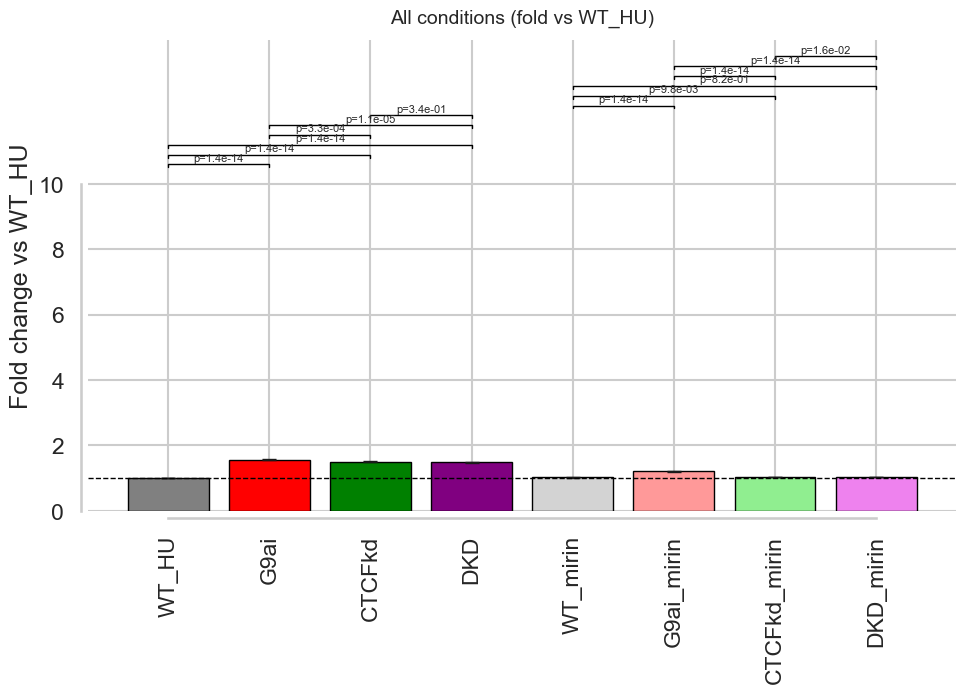

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early  # dict-like: key -> 1D array/list

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) All conditions (for df)
# ------------------------------------------------------------
order = [
    "IR",
    "WT_HU", "WT_mirin",
    "G9ai", "G9ai_mirin",
    "CTCFkd", "CTCFkd_mirin",
    "DKD", "DKD_mirin",
]

# ------------------------------------------------------------
# 3) Tidy DataFrame (raw values)
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette
# ------------------------------------------------------------
cond_palette = {
    "IR":           "grey",
    "WT_HU":        "grey",
    "WT_mirin":     "lightgrey",

    "G9ai":         "red",
    "G9ai_mirin":   "#ff9999",

    "CTCFkd":       "green",
    "CTCFkd_mirin": "lightgreen",

    "DKD":          "purple",
    "DKD_mirin":    "violet",
}

# ------------------------------------------------------------
# 5) Helper: one fold-change bar plot with p-values ABOVE bar_max,
#    only within normal and within mirin groups
# ------------------------------------------------------------
def make_fc_bar(ax, subset, title):
    """
    subset: list of condition names to show as bars
    title:  subplot title
    """
    # WT baseline mean
    wt_vals = np.asarray(data[WT_KEY], dtype=float)
    wt_mean = wt_vals.mean()

    # fold-change stats
    fc_means = []
    fc_sems  = []

    for cond in subset:
        vals = np.asarray(data[cond], dtype=float)
        fc_vals = vals / wt_mean  # per-replicate fold change

        fc_means.append(fc_vals.mean())
        if len(fc_vals) > 1:
            fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
        else:
            fc_sems.append(0.0)

    fc_means = np.array(fc_means)
    fc_sems  = np.array(fc_sems)

    # bar plot
    x = np.arange(len(subset))

    bars = ax.bar(
        x,
        fc_means,
        yerr=fc_sems,
        capsize=5,
        linewidth=1.0,
        edgecolor="black",
    )

    for bar, cond in zip(bars, subset):
        bar.set_facecolor(cond_palette[cond])

    # baseline WT fold change = 1
    ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(subset, rotation=90)  # xticks 90°
    ax.set_ylabel("Fold change vs WT_HU")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=12)

    # --- p-values: within normal group & within mirin group only ---
    cond_to_x = {c: i for i, c in enumerate(subset)}

    normal_group = ["WT_HU", "G9ai", "CTCFkd", "DKD"]
    mirin_group  = ["WT_mirin", "G9ai_mirin", "CTCFkd_mirin", "DKD_mirin"]

    normal_in_subset = [c for c in subset if c in normal_group]
    mirin_in_subset  = [c for c in subset if c in mirin_group]

    pairs_normal = list(combinations(normal_in_subset, 2))
    pairs_mirin  = list(combinations(mirin_in_subset, 2))
    pairs = pairs_normal + pairs_mirin

    # axis:
    # - 0–10: bars
    # - >10: p-values, with fixed step between them
    y_min = 0.0
    bar_max = 10.0          # <- bar region max now 10

    pv_bottom = bar_max + 0.2        # first bracket starts above 10
    step = 0.3                       # vertical distance between p-value rows

    pv_top = pv_bottom + step * (len(pairs) + 1)
    y_max_plot = pv_top + step       # small margin above last row

    for i, (c1, c2) in enumerate(pairs):
        x1 = cond_to_x[c1]
        x2 = cond_to_x[c2]

        g1 = df.loc[df["Condition"] == c1, "Value"]
        g2 = df.loc[df["Condition"] == c2, "Value"]

        stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

        y = pv_bottom + step * (i + 1)
        y_top = y + step * 0.3
        y_text = y + step * 0.45

        # bracket
        ax.plot(
            [x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.0,
            c="black",
        )

        # p-value text
        ax.text(
            (x1 + x2) / 2,
            y_text,
            f"p={pval:.1e}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # final axis: ticks only on bar region up to 10
    ax.set_ylim(y_min, y_max_plot)
    ax.set_yticks([0, 2, 4, 6, 8, 10])

# ------------------------------------------------------------
# 6) Single subplot with all (non-IR) conditions
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

subset_all = [
    "WT_HU", "G9ai", "CTCFkd", "DKD",
    "WT_mirin", "G9ai_mirin", "CTCFkd_mirin", "DKD_mirin",
]
# If you want IR as a bar too, just prepend "IR" to subset_all.

make_fc_bar(ax, subset_all, "All conditions (fold vs WT_HU)")

sns.despine(ax=ax, offset=5, trim=True)

plt.tight_layout()
plt.xticks(rotation=90)

plt.savefig("./fig_1/hct_3hrs_greterthan2_foldchange_bar_all_pval_within_groups_max10.svg",
            format="svg", dpi=1200)
plt.show()


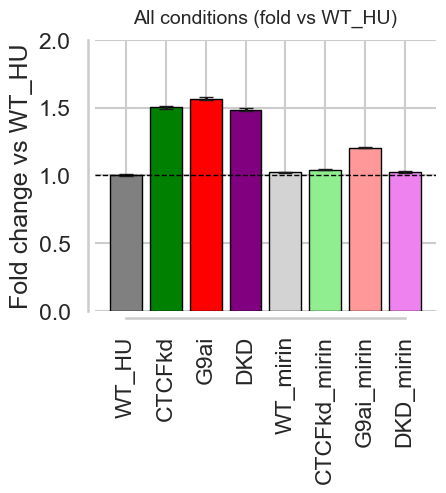

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early  # dict-like: key -> 1D array/list

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) All conditions (for df)
# ------------------------------------------------------------
order = [
    "IR",
    "WT_HU", "WT_mirin",
    "CTCFkd", "CTCFkd_mirin",
    "G9ai", "G9ai_mirin",
    "DKD", "DKD_mirin",
]

# ------------------------------------------------------------
# 3) Tidy DataFrame (raw values)
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette
# ------------------------------------------------------------
cond_palette = {
    "IR":           "grey",
    "WT_HU":        "grey",
    "WT_mirin":     "lightgrey",

    "G9ai":         "red",
    "G9ai_mirin":   "#ff9999",

    "CTCFkd":       "green",
    "CTCFkd_mirin": "lightgreen",

    "DKD":          "purple",
    "DKD_mirin":    "violet",
}

# ------------------------------------------------------------
# 5) Helper: fold-change bar plot (NO p-values)
# ------------------------------------------------------------
def make_fc_bar(ax, subset, title):
    """
    subset: list of condition names to show as bars
    title:  subplot title
    """
    # WT baseline mean
    wt_vals = np.asarray(data[WT_KEY], dtype=float)
    wt_mean = wt_vals.mean()

    # fold-change stats
    fc_means = []
    fc_sems  = []

    for cond in subset:
        vals = np.asarray(data[cond], dtype=float)
        fc_vals = vals / wt_mean  # per-replicate fold change

        fc_means.append(fc_vals.mean())
        if len(fc_vals) > 1:
            fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
        else:
            fc_sems.append(0.0)

    fc_means = np.array(fc_means)
    fc_sems  = np.array(fc_sems)

    # bar plot
    x = np.arange(len(subset))

    bars = ax.bar(
        x,
        fc_means,
        yerr=fc_sems,
        capsize=5,
        linewidth=1.0,
        edgecolor="black",
    )

    for bar, cond in zip(bars, subset):
        bar.set_facecolor(cond_palette[cond])

    # baseline WT fold change = 1
    ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(subset, rotation=90)  # xticks 90°
    ax.set_ylabel("Fold change vs WT_HU")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=14, pad=12)

    # y-axis: 0–5
    ax.set_ylim(0, 2)
    # ax.set_yticks([0, 1, 2, 3,4])

# ------------------------------------------------------------
# 6) Single subplot with all (non-IR) conditions
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(5, 4))

subset_all = [
    "WT_HU", "CTCFkd", "G9ai", "DKD",
    "WT_mirin", "CTCFkd_mirin", "G9ai_mirin", "DKD_mirin",
]
# If you want IR as a bar too, just prepend "IR" to subset_all.

make_fc_bar(ax, subset_all, "All conditions (fold vs WT_HU)")

sns.despine(ax=ax, offset=5, trim=True)

plt.tight_layout()
plt.xticks(rotation=90)

plt.savefig("./fig_1/hct_3hrs_lessthan2_foldchange_bar_all_NOPVAL_2.svg",
            format="svg", dpi=1200)
plt.show()
